# 23. Preprocessing Test (Pipeline 04)

- Goal: inspect monocular pose quality preprocessing on the default recording with the selected exercise definition.
- Docs: `docs_eng/pipeline/04_preprocessing.md` / `docs/pipeline/04_preprocessing.md`
- Inputs: Annotated pose dataframe from prior-stage cells and the selected exercise-definition YAML.
- Outputs: In-memory dataframes/reports unless a cell explicitly saves under `data/processed/`.
- Checks: Preprocessing report, validity flags, and compact before/after QC views.


In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import json
from pathlib import Path

import numpy as np
import pandas as pd

from movement.annotation import apply_annotation, load_annotation_csv
from movement.config import LANDMARKS, make_coordinate_columns, make_required_columns, make_visibility_columns
from movement.exercise_definition import load_exercise_definition
from movement.io import load_pose_csv
from movement.pipeline import (
    InterpolationConfig,
    PipelineConfig,
    PreprocessingConfig,
    ReliabilityConfig,
    SmoothingConfig,
    SwapDetectionConfig,
    run_pipeline,
)
from movement.preprocessing import preprocess_pose_dataframe
from movement.validation import run_basic_validation

print('imports OK')

imports OK


## Data Setup

Mirrors the pipeline order: validation → annotation → exercise_definition → preprocessing.

In [3]:
from pathlib import Path

PROJECT_ROOT = Path.cwd().resolve()
while not (PROJECT_ROOT / "pyproject.toml").exists():
    if PROJECT_ROOT.parent == PROJECT_ROOT:
        raise RuntimeError("Could not find project root containing pyproject.toml")
    PROJECT_ROOT = PROJECT_ROOT.parent

csv_path = PROJECT_ROOT / "data/pose/mediapipe/no_consent/20260517/p01_squat_set1_output_pose.csv"
ann_path = PROJECT_ROOT / "data/pose/mediapipe/no_consent/20260517/p01_squat_set1_annotation.csv"
DEFINITIONS_DIR = PROJECT_ROOT / "data/definitions/exercises"
AUTHORING_EXAMPLE_ROOT = PROJECT_ROOT / "data/examples/exercise_authoring"
AUTHORING_DRAFT_ROOT = PROJECT_ROOT / "data/processed/authoring_drafts"

# Default stage-check target. The p01 sample uses the authoring-generated draft_squat bundle.
TARGET_EXERCISE_ID = "draft_squat"


def candidate_definition_dirs(exercise_id):
    return [
        DEFINITIONS_DIR,
        AUTHORING_DRAFT_ROOT / exercise_id / "data/definitions/exercises",
        AUTHORING_EXAMPLE_ROOT / exercise_id / "data/definitions/exercises",
    ]


def resolve_target_definitions_dir(exercise_id):
    for definitions_dir in candidate_definition_dirs(exercise_id):
        if (definitions_dir / f"{exercise_id}.yaml").exists():
            return definitions_dir
    return DEFINITIONS_DIR


TARGET_DEFINITIONS_DIR = resolve_target_definitions_dir(TARGET_EXERCISE_ID)

df_raw = load_pose_csv(csv_path)
print(f"loaded: {df_raw.shape[0]} frames, {df_raw.shape[1]} columns")
print(f"target exercise_id : {TARGET_EXERCISE_ID}")
print(f"definitions_dir    : {TARGET_DEFINITIONS_DIR}")


loaded: 884 frames, 237 columns
target exercise_id : draft_squat
definitions_dir    : C:\Users\andi9\Desktop\DEV\source\movement_project\data\processed\authoring_drafts\draft_squat\data\definitions\exercises


In [4]:
val_report = run_basic_validation(
    df=df_raw,
    required_columns=make_required_columns(LANDMARKS),
    coordinate_columns=make_coordinate_columns(LANDMARKS),
    visibility_columns=make_visibility_columns(LANDMARKS),
)
print(f'top-level validation passed: {val_report["passed"]}')
print(f'structural passed: {val_report.get("structural_passed")}')
for name, item in val_report.items():
    if isinstance(item, dict) and 'passed' in item:
        print(f'  {name}: {item["passed"]}')
if val_report.get('warnings'):
    print('validation warnings:')
    for warning in val_report['warnings']:
        print(f'  {warning["check"]}: {warning["message"]}')
if not val_report['passed']:
    print('NOTE: structural validation failed; inspect before preprocessing.')


top-level validation passed: True
structural passed: True
  required_columns: True
  frame_continuity: True
  timestamp: True
  missing_values: True
  visibility: False
validation warnings:
  visibility: Low or unavailable visibility is handled by downstream reliability gates.


In [5]:
ann_df = load_annotation_csv(ann_path)
df_annotated, ann_report = apply_annotation(df_raw, ann_df)
print(f'annotated: exercise_type={df_annotated["exercise_type"].unique()}')
print(f'analysis frames: {ann_report["num_analysis_frames"]} / {ann_report["num_total_frames"]}')

annotated: exercise_type=[None 'squat']
analysis frames: 637 / 884


In [6]:
exercise_def = load_exercise_definition(
    exercise_id=TARGET_EXERCISE_ID,
    definitions_dir=TARGET_DEFINITIONS_DIR,
)
print(f"exercise_id        : {exercise_def.exercise_id}")
print(f"version            : {exercise_def.version}")
print(f"laterality         : {exercise_def.classification['laterality']}")
print(f"is_generic_fallback: {exercise_def.is_generic_fallback}")


exercise_id        : draft_squat
version            : draft
laterality         : bilateral_symmetric
is_generic_fallback: False


## Direct Preprocessing Test

Call `preprocess_pose_dataframe()` directly (not via pipeline) for fine-grained inspection.

In [7]:
pre_config = PreprocessingConfig(
    enabled=True,
    reliability=ReliabilityConfig(
        visibility_threshold=0.5,
        segment_length_tolerance=0.25,
        joint_angle_check=True,
        velocity_threshold_torso_per_sec=5.0,
    ),
    interpolation=InterpolationConfig(enabled=True, method='linear', max_gap_frames=3),
    smoothing=SmoothingConfig(enabled=False),
)

pre_df, pre_report = preprocess_pose_dataframe(
    df=df_annotated,
    landmarks=LANDMARKS,
    exercise_definition=exercise_def,
    config=pre_config,
)
print(f'output shape: {pre_df.shape}')
added = [c for c in pre_df.columns if c not in df_annotated.columns]
print(f'added {len(added)} columns: {added[:6]} ...')

output shape: (884, 299)
added 36 columns: ['nose_reliable', 'left_eye_inner_reliable', 'left_eye_reliable', 'left_eye_outer_reliable', 'right_eye_inner_reliable', 'right_eye_reliable'] ...


## Check 1: Output Columns Present (criteria 1, 2, 9)

In [8]:
for col in ('preprocessing_valid', 'preprocessing_note', 'swap_corrected'):
    assert col in pre_df.columns, f'missing: {col}'
print('PASS: frame-level output columns present')

missing_rel = [lm for lm in LANDMARKS if f'{lm}_x' in pre_df.columns
               and f'{lm}_reliable' not in pre_df.columns]
assert not missing_rel, f'missing _reliable: {missing_rel}'
n_lm = sum(1 for lm in LANDMARKS if f'{lm}_x' in pre_df.columns)
print(f'PASS: _reliable columns present for all {n_lm} landmarks')

for col in ('frame', 'timestamp'):
    assert col in pre_df.columns
print('PASS: frame and timestamp columns preserved (criteria 9)')

PASS: frame-level output columns present
PASS: _reliable columns present for all 33 landmarks
PASS: frame and timestamp columns preserved (criteria 9)


## Check 2: p01 Reliability Summary (criteria 3, 4)


In [9]:
n_invalid = int((~pre_df['preprocessing_valid']).sum())
print(f'preprocessing_valid=False : {n_invalid} / {len(pre_df)}')

rel_cols = [f'{lm}_reliable' for lm in LANDMARKS if f'{lm}_x' in pre_df.columns]
unreliable = sum(int((~pre_df[c]).sum()) for c in rel_cols)
print(f'unreliable landmark-frames: {unreliable}')

summary = pd.DataFrame([
    {
        'num_frames': len(pre_df),
        'num_invalid_frames': n_invalid,
        'unreliable_landmark_frames': unreliable,
        'valid_frame_fraction': 1.0 - n_invalid / max(len(pre_df), 1),
    }
])
display(summary)


preprocessing_valid=False : 598 / 884
unreliable landmark-frames: 3685


,num_frames,num_invalid_frames,unreliable_landmark_frames,valid_frame_fraction
0,884,598,3685,0.323529


## Check 3: Swap Detection Skipped for bilateral_symmetric (criteria 5)

In [10]:
n_swap = int(pre_df['swap_corrected'].sum())
print(f'swap_corrected=True frames: {n_swap}')
assert n_swap == 0
print('PASS: no swap corrections (bilateral_symmetric → skip)')

assert pre_report['swap_detection_summary']['enabled'] is False
print('PASS: report.swap_detection_summary.enabled = False')

swap_corrected=True frames: 0
PASS: no swap corrections (bilateral_symmetric → skip)
PASS: report.swap_detection_summary.enabled = False


## Check 4: Interpolation Summary (criteria 6, 7)


In [11]:
itp = pre_report['interpolation_summary']
print(f'interpolation enabled   : {itp["enabled"]}')
print(f'short gaps interpolated : {itp["num_short_gaps_interpolated"]}')
print(f'long gaps unresolved    : {itp["num_long_gaps_unresolved"]}')
print('NOTE: non-zero values are expected inspection provenance for real recordings.')


interpolation enabled   : True
short gaps interpolated : 77
long gaps unresolved    : 167
NOTE: non-zero values are expected inspection provenance for real recordings.


## Check 5: Smoothing Off by Default (criteria 8)

In [12]:
sm = pre_report['smoothing_summary']
assert sm['enabled'] is False
assert sm['applied_columns'] == []
print(f'PASS: smoothing disabled by default, applied_columns=[]')

PASS: smoothing disabled by default, applied_columns=[]


## Check 6: Full Report Structure (criteria 10)

In [13]:
required_keys = [
    'method', 'exercise_type', 'pattern', 'laterality',
    'num_frames', 'num_coordinate_columns',
    'reliability_summary', 'swap_detection_summary',
    'interpolation_summary', 'smoothing_summary',
    'num_invalid_frames', 'applied_columns',
]
for k in required_keys:
    assert k in pre_report, f'missing: {k}'
print('PASS: all required report keys present')
print()
print(json.dumps(pre_report, indent=2, default=str)[:2000])

PASS: all required report keys present

{
  "method": "reliability_mask_v1",
  "exercise_type": "None",
  "pattern": "None",
  "laterality": "bilateral_symmetric",
  "num_frames": 884,
  "num_coordinate_columns": 99,
  "reliability_summary": {
    "visibility_threshold": 0.5,
    "num_low_visibility_frames_per_landmark": {
      "nose": 17,
      "left_eye_inner": 25,
      "left_eye": 26,
      "left_eye_outer": 22,
      "right_eye_inner": 19,
      "right_eye": 18,
      "right_eye_outer": 14,
      "left_ear": 21,
      "right_ear": 16,
      "mouth_left": 13,
      "mouth_right": 12,
      "left_shoulder": 0,
      "right_shoulder": 0,
      "left_elbow": 120,
      "right_elbow": 440,
      "left_wrist": 124,
      "right_wrist": 299,
      "left_pinky": 125,
      "right_pinky": 225,
      "left_index": 124,
      "right_index": 274,
      "left_thumb": 124,
      "right_thumb": 357,
      "left_hip": 0,
      "right_hip": 0,
      "left_knee": 145,
      "right_knee": 177,
    

## Check 7: Report Values for p01 Squat


In [14]:
assert pre_report['num_frames'] == len(pre_df)

rel = pre_report['reliability_summary']
report_summary = pd.DataFrame([
    {
        'exercise_type': pre_report.get('exercise_type'),
        'pattern': pre_report.get('pattern'),
        'laterality': pre_report.get('laterality'),
        'num_invalid_frames': pre_report['num_invalid_frames'],
        'num_segment_length_violations': rel['num_segment_length_violations'],
        'num_joint_angle_violations': rel['num_joint_angle_violations'],
        'num_velocity_outliers': rel['num_velocity_outliers'],
        'num_unreliable_landmark_frames': rel['num_unreliable_landmark_frames'],
    }
])
display(report_summary)
print('PASS: p01 preprocessing report structure is valid; counts are data-quality provenance.')


,exercise_type,pattern,laterality,num_invalid_frames,num_segment_length_violations,num_joint_angle_violations,num_velocity_outliers,num_unreliable_landmark_frames
0,None,None,bilateral_symmetric,598,0,27,0,3685


PASS: p01 preprocessing report structure is valid; counts are data-quality provenance.


## Task B Review: Far-Side Jitter / Feature Availability

Synthetic side-view perturbation to verify that ④ Preprocessing can mark far-side landmark jitter as observation confidence, not movement-quality failure.


,observed_zones,near_side_landmark_frames,far_side_landmark_frames,unknown_side_landmark_frames,high_jitter_far_side_frames,symmetry_gate_ready,low_confidence_features,not_assessed_features
0,Z3,0,0,29172,0,False,spatial.symmetry.*,


NOTE: this optional perturbation diagnostic is inspection-only for p01; counts may be zero depending on camera-side inference.


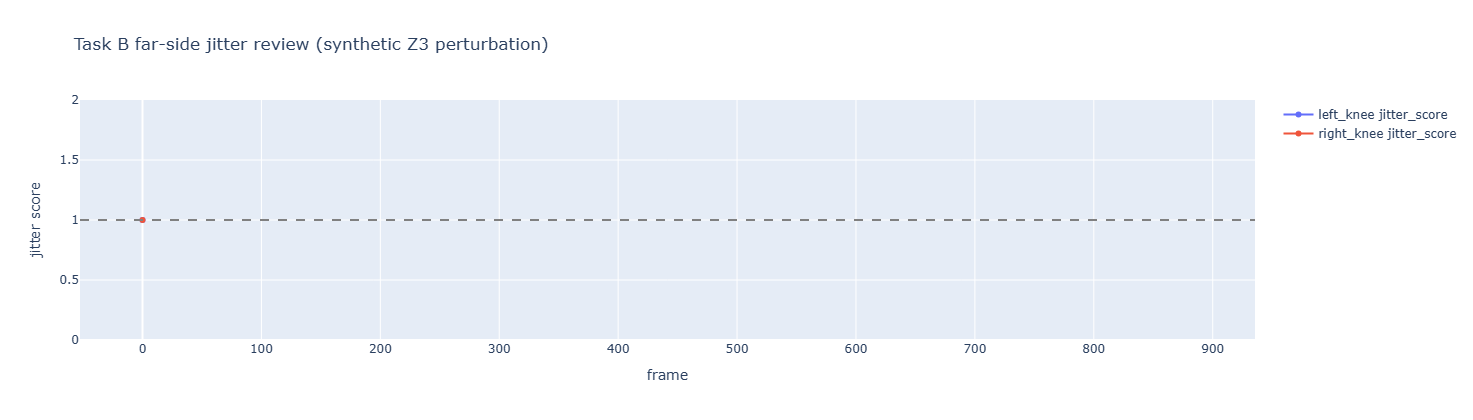

In [15]:
from movement.pipeline import FarSideStabilizationConfig
import plotly.graph_objects as go

side_view_df = df_annotated.copy()
side_view_df['camera_zone'] = 'Z3'

left_side_landmarks = ['left_shoulder', 'left_hip', 'left_knee', 'left_ankle']
right_side_landmarks = ['right_shoulder', 'right_hip', 'right_knee', 'right_ankle']
for lm in left_side_landmarks:
    col = f'{lm}_z'
    if col in side_view_df.columns:
        side_view_df[col] = -0.2
for lm in right_side_landmarks:
    col = f'{lm}_z'
    if col in side_view_df.columns:
        side_view_df[col] = 0.2

jitter_frame = len(side_view_df) // 2
side_view_df.loc[jitter_frame, 'right_knee_x'] = side_view_df.loc[jitter_frame, 'right_knee_x'] + 1.0
if 'right_knee_visibility' in side_view_df.columns:
    side_view_df.loc[jitter_frame, 'right_knee_visibility'] = 0.2

far_side_config = PreprocessingConfig(
    enabled=True,
    reliability=ReliabilityConfig(
        visibility_threshold=0.5,
        segment_length_tolerance=0.25,
        joint_angle_check=True,
        velocity_threshold_torso_per_sec=5.0,
    ),
    interpolation=InterpolationConfig(enabled=False),
    smoothing=SmoothingConfig(enabled=False),
    far_side_stabilization=FarSideStabilizationConfig(
        enabled=True,
        jitter_threshold_torso_per_sec=1.0,
        acceleration_threshold_torso_per_sec2=30.0,
        max_gap_frames=1,
    ),
)

far_pre_df, far_pre_report = preprocess_pose_dataframe(
    df=side_view_df,
    landmarks=LANDMARKS,
    exercise_definition=exercise_def,
    config=far_side_config,
)

far_summary = far_pre_report['far_side_stabilization_summary']
availability = far_pre_report['feature_availability_summary']

summary_df = pd.DataFrame([
    {
        'observed_zones': ', '.join(far_summary['camera_side_inference']['observed_zones']),
        'near_side_landmark_frames': far_summary['num_near_side_landmark_frames'],
        'far_side_landmark_frames': far_summary['num_far_side_landmark_frames'],
        'unknown_side_landmark_frames': far_summary['num_unknown_side_landmark_frames'],
        'high_jitter_far_side_frames': far_summary['num_high_jitter_far_side_landmark_frames'],
        'symmetry_gate_ready': availability['symmetry_gate_ready'],
        'low_confidence_features': ', '.join(availability['low_confidence_feature_families']),
        'not_assessed_features': ', '.join(availability['not_assessed_feature_families']),
    }
])
display(summary_df)

assert far_summary['enabled'] is True
print('NOTE: this optional perturbation diagnostic is inspection-only for p01; counts may be zero depending on camera-side inference.')

fig = go.Figure()
for lm in ['left_knee', 'right_knee']:
    fig.add_scatter(
        x=far_pre_df['frame'],
        y=far_pre_df[f'{lm}_jitter_score'],
        mode='lines+markers',
        name=f'{lm} jitter_score',
    )
fig.add_hline(y=1.0, line_dash='dash', line_color='gray')
fig.update_layout(
    title='Task B far-side jitter review (synthetic Z3 perturbation)',
    xaxis_title='frame',
    yaxis_title='jitter score',
    height=420,
)
fig


## Check 8: Pipeline Integration (criteria 11)

In [16]:
import warnings

pipe_config = PipelineConfig()
pipe_config.preprocessing = PreprocessingConfig(enabled=True)
pipe_config.exercise_definition.exercise_id = TARGET_EXERCISE_ID
pipe_config.exercise_definition.definitions_dir = str(TARGET_DEFINITIONS_DIR)

with warnings.catch_warnings(record=True):
    warnings.simplefilter("always")
    pipe_df, pipe_report = run_pipeline(
        df_annotated,
        config=pipe_config,
        landmarks=LANDMARKS,
    )

assert "preprocessing" in pipe_report
assert pipe_report["exercise_definition"]["exercise_id"] == TARGET_EXERCISE_ID
print("PASS: preprocessing step in pipeline report")
print(f"steps executed: {list(pipe_report.keys())}")
print(f"pipeline exercise_id: {pipe_report['exercise_definition']['exercise_id']}")
print(f"pipeline output shape: {pipe_df.shape}")
print(f"pipeline preprocessing invalid frames: {pipe_report['preprocessing']['num_invalid_frames']}")


PASS: preprocessing step in pipeline report
steps executed: ['validation', 'exercise_definition', 'preprocessing', 'normalization']
pipeline exercise_id: draft_squat
pipeline output shape: (884, 405)
pipeline preprocessing invalid frames: 598


## Check Summary

This notebook cell is a compact execution/QC checkpoint. Use the pipeline document linked in the header for definitions, interpretation policy, and scope.
